# NMF restrito — subtemas dentro dos tópicos de aspecto genuíno (`youtube_sent`, STM K=15)

Refinamento pós-STM para RQ4 (`docs/idealizacao-artigo.txt` §5.2/§6): decompõe, **tópico a
tópico**, as sentenças dos 8 tópicos do STM de sentença (K=15) classificados como "aspecto
genuíno" (ou limítrofe) em subtemas mais específicos (ex.: dentro de "battery/cooling",
separar "duração da bateria" de "ruído de ventoinha"). Serve de *scaffold* para a revisão
humana de elicitação de requisitos — **não** é comparação de modelo com o STM nem uma 5ª
granularidade, por isso não herda a faixa de K nem o `no_below` do corpus inteiro
(`nmf_restrito.youtube_sent` em `params.yaml`, bloco próprio).

**Reroda este notebook uma vez por tópico**, trocando `TOPIC_ID` na célula de configuração
entre os 8 valores de `aspect_topics`.


In [1]:
# ── path fix: resolve _helpers.py e data/ de qualquer subdiretório ──
import sys as _sys, os as _os
from pathlib import Path as _P
_here = _P().resolve()
_nb_dir = _here if (_here / '_helpers.py').exists() else _here.parent
if str(_nb_dir) not in _sys.path:
    _sys.path.insert(0, str(_nb_dir))
_os.chdir(_nb_dir)          # '../data/...' paths ficam corretos
del _here, _nb_dir, _P, _sys, _os
# ─────────────────────────────────────────────────────────────────────
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from gensim.corpora import Dictionary

from _helpers import load_params, get_corpus_config, get_seed, resolve_latest_dir, make_run_output_dir
from _helpers import grid_search_k_nmf, train_nmf, extract_topics_keywords, compute_doc_distributions
from _helpers import name_all_topics, export_results, export_topics_for_eval
from _selecao import _pareto


In [2]:
# === CONFIGURAÇÃO — troque TOPIC_ID aqui a cada rodada =====================
CORPUS_ID = "youtube_sent"
TOPIC_ID = 12  # << um de aspect_topics: 1, 3, 4, 6, 8, 10, 11, 12
# =============================================================================

# Nomes vêm da classificação em docs/idealizacao-artigo.txt §5.2 (efeito de
# product_category por tópico) — não persistidos em stm_final.json, por isso
# hardcoded aqui em vez de recarregados.
ASPECT_TOPIC_NAMES = {
    1: "Keyboard build/design",
    3: "Price/value",
    4: "Battery/cooling",
    6: "Speakers/software",
    8: "Appearance/finish",
    10: "Ports/connectivity",
    11: "Display/brightness",
    12: "Gaming frame rate (limítrofe)",
}

params = load_params()
_, cfg = get_corpus_config(params, CORPUS_ID)
seed = get_seed(params)
LANG = cfg.get("language", "en")

NMF_R = params["nmf_restrito"][CORPUS_ID]
ASPECT_TOPICS = NMF_R["aspect_topics"]
assert TOPIC_ID in ASPECT_TOPICS, f"TOPIC_ID={TOPIC_ID} não está entre os aspectos genuínos {ASPECT_TOPICS}"

STM_RUN = NMF_R["stm_run"]
NO_BELOW = NMF_R["no_below"]
NO_ABOVE = NMF_R["no_above"]
K_MIN, K_MAX = NMF_R["k_range"]

print(f"corpus={CORPUS_ID}  topic_id={TOPIC_ID} ({ASPECT_TOPIC_NAMES[TOPIC_ID]})")
print(f"stm_run={STM_RUN}  no_below={NO_BELOW}  no_above={NO_ABOVE}  k_range=[{K_MIN},{K_MAX}]")


corpus=youtube_sent  topic_id=12 (Gaming frame rate (limítrofe))
stm_run=youtube_sent_20260921_190124  no_below=5  no_above=0.5  k_range=[2,6]


## 1. Sentenças do tópico (reconstrução alinhada ao STM final)

`stm_input.csv` guarda **duas coisas por linha**: o texto já lematizado (join dos tokens
usados pelo STM) e uma coluna chamada `post_id` — mas essa coluna é o `post_id` **literal**
do dataframe de origem (`prepare_stm_input()` em `_helpers.py` não usa o
`post_id_column` configurado por corpus), que para `youtube_sent` é o **video id**, não o
`sent_id` da sentença (`corpus_sentencas.csv` tem as duas colunas, `post_id`=video e
`sent_id`=sentença — achado do code review: um merge por essa coluna nunca bate).

Sem uma chave de sentença confiável em `stm_input.csv`, o alinhamento correto vem de
**reproduzir exatamente os mesmos filtros pré-STM**, na mesma ordem, sobre a mesma versão
do corpus — a mesma lógica que já está inline no `02_stm_youtube_sent.ipynb`. Isso
reconstrói uma linha por sentença, na mesma ordem de `stm_input.csv`, de onde dá pra puxar
`sent_id`/`sentence` por **posição** (verificado abaixo com `assert` de contagem e de
`product_category`, não só torcendo pra bater).


In [3]:
sent_dir = resolve_latest_dir("../../02-sentences/data/output/youtube_sent", contains="corpus_sentencas.csv")
raw = pd.read_csv(sent_dir / "corpus_sentencas.csv", dtype={"sent_id": str, "post_id": str})

MIN_TOKENS = int(cfg.get("stm_min_tokens_per_doc", 0) or 0)
COV_COLS = cfg.get("covariates", [])

# Mesmos 3 filtros, na mesma ordem, de 02_stm_youtube_sent.ipynb (secao "Limpeza pre-STM")
df_full = raw[(~raw["is_fragment"]) & (~raw["is_dup_exact"])].reset_index(drop=True)
df_full = df_full.dropna(subset=COV_COLS).reset_index(drop=True)
df_full = df_full[df_full["n_words"] >= MIN_TOKENS].reset_index(drop=True)

STM_DIR = Path(f"../data/output/{CORPUS_ID}/stm/{STM_RUN}")
stm_input = pd.read_csv(STM_DIR / "stm_input.csv")
theta = pd.read_csv(STM_DIR / "stm_theta.csv")
stm_final = json.loads((STM_DIR / "stm_final.json").read_text(encoding="utf-8"))

assert len(df_full) == len(stm_input), (
    f"df_full ({len(df_full)}) != stm_input.csv ({len(stm_input)}) — versao do corpus "
    "ou filtros pre-STM mudaram desde o run do STM; reconstrucao por posicao nao e segura"
)
assert (df_full["product_category"].values == stm_input["product_category"].values).all(),     "product_category desalinhado entre df_full e stm_input.csv — reconstrucao invalida"

docs_removed = set(stm_final.get("docs_removed", []))
keep_idx = [i for i in range(len(df_full)) if i not in docs_removed]
df_kept = df_full.iloc[keep_idx].reset_index(drop=True)
df_kept["text"] = stm_input.iloc[keep_idx]["text"].reset_index(drop=True)  # texto lematizado, mesma posicao
assert len(df_kept) == len(theta), (len(df_kept), len(theta))
print(f"corpus reconstruido: {len(raw):,} brutas -> {len(df_full):,} pre-STM -> {len(df_kept):,} pos docs_removed (alinhado com theta)")

dominant = theta.to_numpy().argmax(axis=1)
df_kept["stm_topic_id"] = dominant

subset = df_kept[df_kept["stm_topic_id"] == TOPIC_ID].reset_index(drop=True)
print(f"Sentenças no tópico {TOPIC_ID} ({ASPECT_TOPIC_NAMES[TOPIC_ID]}): {len(subset):,} de {len(df_kept):,}")
subset[["sent_id", "product_category", "sentence"]].head(3)


  versão resolvida: youtube_sent_20260920_141442/ (latest)


corpus reconstruido: 130,016 brutas -> 116,111 pre-STM -> 114,888 pos docs_removed (alinhado com theta)
Sentenças no tópico 12 (Gaming frame rate (limítrofe)): 5,298 de 114,888


,sent_id,product_category,sentence
0,WmhKCq0vfjE_4,headphone,You keep recommending them to me so when they ...
1,07mIwEa3xbQ_16,watch,So now player four enters the game.
2,07mIwEa3xbQ_86,watch,"And then there's the stress app, which just te..."


## 2. Tokens (reaproveita a lematização do STM — mesmo vocabulário-base)

`text` em `stm_input.csv` é `" ".join(tokenized)` — os mesmos lemas que alimentaram o STM,
antes do `filter_extremes` do STM (que só afetou o `Dictionary`, não a lista de tokens).
Aqui construímos um `Dictionary` **próprio** deste subconjunto, com `no_below`/`no_above`
do NMF restrito (bem menor que o do corpus inteiro — o subconjunto é pequeno).


In [4]:
tokenized_subset = [t.split(" ") if isinstance(t, str) and t else [] for t in subset["text"]]
dictionary = Dictionary(tokenized_subset)
dictionary.filter_extremes(no_below=NO_BELOW, no_above=NO_ABOVE)
corpus_bow = [dictionary.doc2bow(t) for t in tokenized_subset]
non_empty = sum(1 for d in corpus_bow if len(d) > 0)
print(f"Vocabulário: {len(dictionary):,} tokens | docs com BoW não-vazio: {non_empty:,}/{len(corpus_bow):,}")


Vocabulário: 1,005 tokens | docs com BoW não-vazio: 5,298/5,298


## 3. Grid de K (pequeno — subtemas, não a faixa admissível do corpus geral)

NPMI e Diversity **decidem** (mesma régua do §1.6 do protocolo: sem perplexidade, sem
terceiro eixo); C_v é calculado e plotado só como **reporte** (§1.3), nunca entra na
decisão. Sem faixa admissível [9,15]/[10,40] — não se aplica a subtemas dentro de um
tópico já isolado.


In [5]:
BASE_OUTPUT_DIR = Path(f"../data/output/{CORPUS_ID}/nmf/topic{TOPIC_ID:02d}")
BASE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
diag_path = BASE_OUTPUT_DIR / "nmf_grid_k_diagnostics.csv"
grid_cfg_path = BASE_OUTPUT_DIR / "nmf_grid_config.json"
grid_cfg = {"stm_run": STM_RUN, "no_below": NO_BELOW, "no_above": NO_ABOVE, "k_min": K_MIN, "k_max": K_MAX}

cache_matches = (
    diag_path.exists() and grid_cfg_path.exists()
    and json.loads(grid_cfg_path.read_text(encoding="utf-8")) == grid_cfg
)
if cache_matches:
    diag_df = pd.read_csv(diag_path)
    print(f"Grid carregado do cache ({diag_path})")
else:
    if diag_path.exists():
        print("Config do grid mudou desde o cache anterior (stm_run/no_below/no_above/k_range) — recomputando.")
    print(f"Grid K em [{K_MIN},{K_MAX}] ({len(corpus_bow):,} sentenças, 10 passes)...")
    t0 = time.time()
    checkpoint_path = BASE_OUTPUT_DIR / "nmf_grid_k_checkpoint.csv"
    cv_scores, npmi_scores, diag_df, diversity_scores = grid_search_k_nmf(
        corpus_bow, dictionary, tokenized_subset, range(K_MIN, K_MAX + 1),
        seed=seed, passes=10, return_npmi=True, return_diagnostics=True,
        return_diversity=True, top_k=params["evaluation"]["top_n_keywords"],
        checkpoint_path=str(checkpoint_path),
    )
    diag_df["npmi"] = diag_df["k"].map(npmi_scores)
    diag_df["diversity"] = diag_df["k"].map(diversity_scores)
    diag_df.to_csv(diag_path, index=False)
    grid_cfg_path.write_text(json.dumps(grid_cfg), encoding="utf-8")
    print(f"  concluído em {time.time()-t0:.0f}s")

print(diag_df.round(4).to_string(index=False))


Grid K em [2,6] (5,298 sentenças, 10 passes)...


  concluído em 50s
 k     cv  h_sparsity  top_topic_doc_share  n_topics_with_docs  docs_sem_topico  elapsed_sec   npmi  diversity
 2 0.4507      0.2572               0.7620                   2                0       8.3791 0.0398     0.8500
 3 0.5149      0.3191               0.5968                   3                0       8.3768 0.0535     0.8667
 4 0.5175      0.3557               0.4026                   4                0       7.9580 0.0624     0.6750
 5 0.5632      0.3829               0.2618                   5                0       7.9350 0.0858     0.7800
 6 0.5190      0.4337               0.3977                   6                0       8.5948 0.0545     0.6833


Salvo: ..\data\output\youtube_sent\nmf\topic12\nmf_grid_k.png


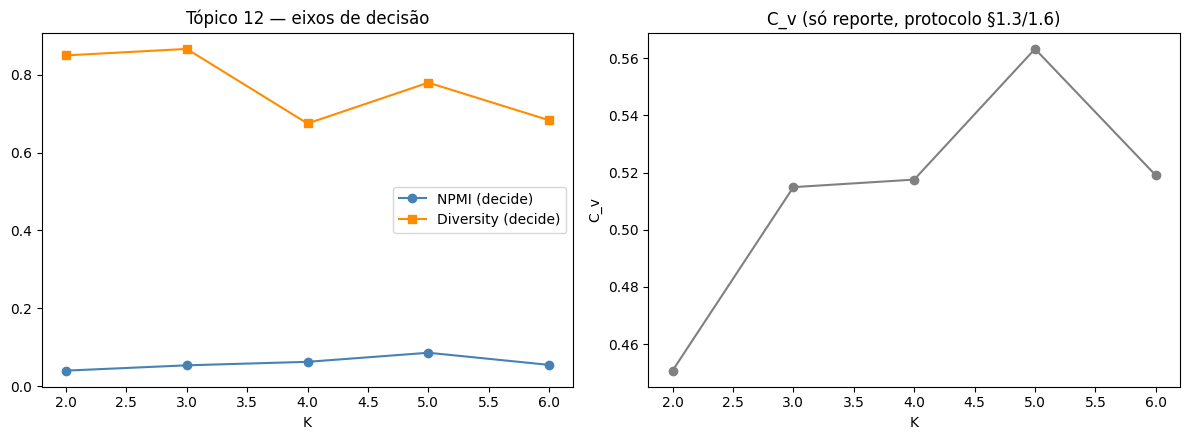

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(diag_df["k"], diag_df["npmi"], marker="o", color="steelblue", label="NPMI (decide)")
axes[0].plot(diag_df["k"], diag_df["diversity"], marker="s", color="darkorange", label="Diversity (decide)")
axes[0].set_xlabel("K"); axes[0].legend(); axes[0].set_title(f"Tópico {TOPIC_ID} — eixos de decisão")
axes[1].plot(diag_df["k"], diag_df["cv"], marker="o", color="gray")
axes[1].set_xlabel("K"); axes[1].set_ylabel("C_v"); axes[1].set_title("C_v (só reporte, protocolo §1.3/1.6)")
plt.tight_layout()
plt.savefig(BASE_OUTPUT_DIR / "nmf_grid_k.png", dpi=150, bbox_inches="tight", facecolor="white")
print(f"Salvo: {BASE_OUTPUT_DIR / 'nmf_grid_k.png'}")
plt.show()


## 4. Seleção de K (fronteira de Pareto NPMI×Diversity, desempate por NPMI, Diversity, menor K)

In [7]:
fr = _pareto(diag_df, ["npmi", "diversity"], verbose=True)
escolhido = fr.sort_values(["npmi", "diversity", "k"], ascending=[False, False, True]).iloc[0]
BEST_K = int(escolhido["k"])

print(f"Fronteira de Pareto (NPMI x Diversity): {len(fr)} de {len(diag_df)} pontos")
print(fr.sort_values("k").round(4).to_string(index=False))
print(f"\n>>> K escolhido: {BEST_K}  (npmi={escolhido['npmi']:.4f}, diversity={escolhido['diversity']:.4f}, cv={escolhido.get('cv', float('nan')):.4f})")


Fronteira de Pareto (NPMI x Diversity): 2 de 5 pontos
 k     cv  h_sparsity  top_topic_doc_share  n_topics_with_docs  docs_sem_topico  elapsed_sec   npmi  diversity
 3 0.5149      0.3191               0.5968                   3                0       8.3768 0.0535     0.8667
 5 0.5632      0.3829               0.2618                   5                0       7.9350 0.0858     0.7800

>>> K escolhido: 5  (npmi=0.0858, diversity=0.7800, cv=0.5632)


## 5. Modelo final (corpus completo do tópico — sem amostragem, já é pequeno)

Defaults do gensim para `kappa`/`minimum_probability` (sem segundo estágio de grid aqui —
esta etapa é *scaffold* de leitura humana, não um braço a ser publicado com o mesmo rigor
do STM/comparação de família; ver decisão registrada na conversa de brainstorming).


In [8]:
print(f"Treinando NMF final K={BEST_K}, 20 passes...")
t0 = time.time()
model = train_nmf(corpus_bow, dictionary, k=BEST_K, seed=seed, passes=20)
print(f"  concluído em {time.time()-t0:.0f}s")

top_n = params["evaluation"]["top_n_keywords"]
topics_keywords = extract_topics_keywords(model, k=BEST_K, top_n=top_n)
for tid, kws in topics_keywords.items():
    print(f"  S{tid}: {', '.join(kws)}")

dominant_sub, full_sub = compute_doc_distributions(model, corpus_bow, BEST_K)


Treinando NMF final K=5, 20 passes...


  concluído em 2s
  S0: run, application, laptop, test, minute, cpu, game, benchmark, loop, fan
  S1: mode, performance, laptop, power, drop, draw, fan, default, balance, watt
  S2: game, play, want, laptop, screen, setting, light, good, title, graphic
  S3: frame, second, rate, setting, graphic, low, drop, get, ultra, gen
  S4: high, end, resolution, rate, refresh, setting, low, screen, fast, speed


## 6. Rotulagem via LLM (subtemas)

In [9]:
full_arr = np.array(full_sub)
N_REPR = 3
example_docs_map = {
    tid: [subset["sentence"].iloc[i] for i in np.argsort(full_arr[:, tid])[::-1][:N_REPR]]
    for tid in range(BEST_K)
}

llm_cfg = params.get("llm", {})
print(f"Nomeando {BEST_K} subtemas via {llm_cfg.get('model')} (lang={LANG})...")
try:
    subtopic_names = name_all_topics(
        topics_keywords, model=llm_cfg["model"], base_url=llm_cfg.get("base_url", "http://localhost:11434"),
        example_docs_map=example_docs_map, lang=LANG,
    )
except Exception as e:
    print(f"LLM falhou ({e}) — fallback top-3 keywords")
    subtopic_names = {tid: ", ".join(kws[:3]) for tid, kws in topics_keywords.items()}

for tid, name in subtopic_names.items():
    print(f"  S{tid}: {name}")


Nomeando 5 subtemas via gemma2:2b-instruct-q4_K_M (lang=en)...


  S0: Benchmark Testing
  S1: Power Consumption
  S2: Gaming Experience
  S3: Action Sequence
  S4: Port Quality


## 7. Visualizações

Run dir: ..\data\output\youtube_sent\nmf\topic12\topic12_20260922_151601


Salvo: ..\data\output\youtube_sent\nmf\topic12\topic12_20260922_151601\nmf_wordclouds.png


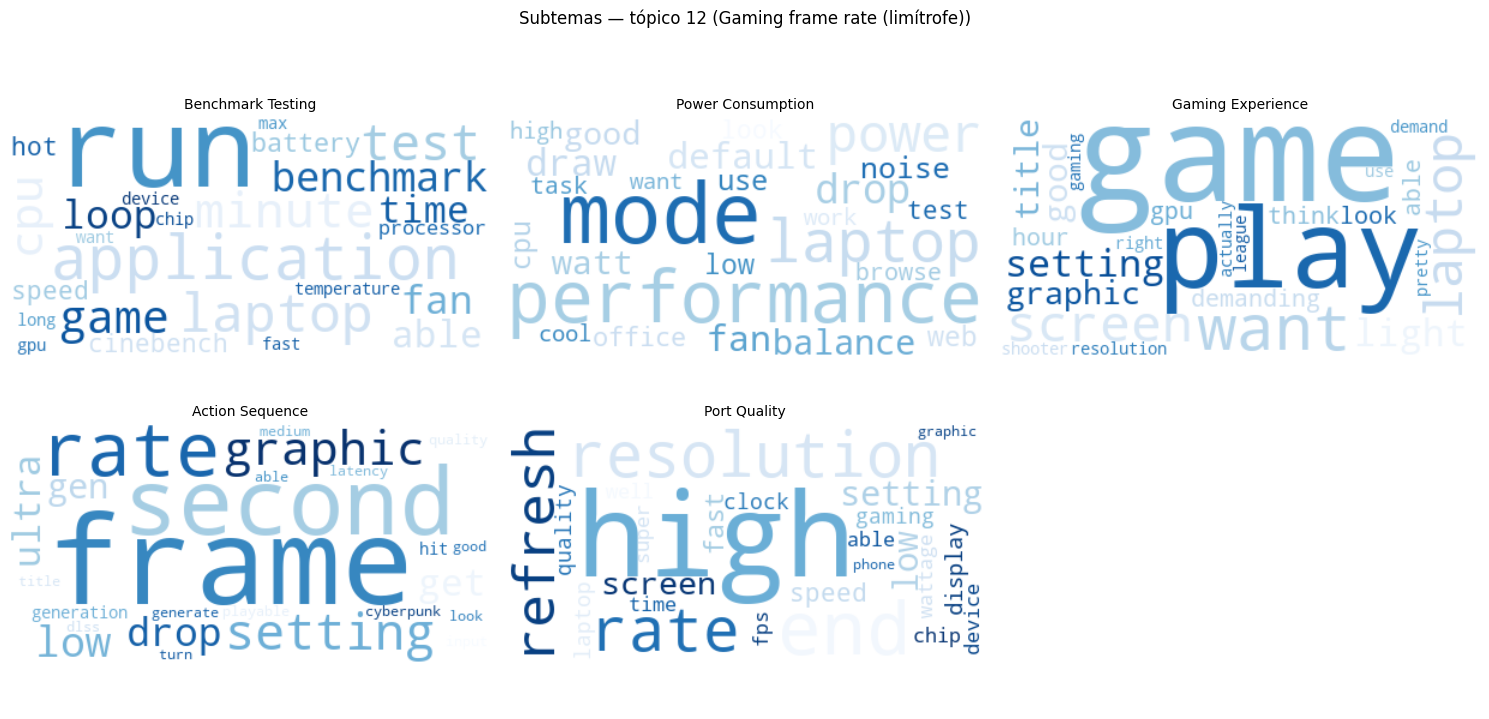

In [10]:
OUTPUT_DIR = make_run_output_dir(BASE_OUTPUT_DIR, f"topic{TOPIC_ID:02d}")
print(f"Run dir: {OUTPUT_DIR}")

try:
    from wordcloud import WordCloud
    ncols = min(3, BEST_K)
    nrows = (BEST_K + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows))
    axes = np.atleast_1d(axes).flatten()
    for i in range(BEST_K):
        ws = dict(model.show_topic(i, topn=30))
        wc = WordCloud(width=400, height=200, background_color="white",
                       max_words=25, colormap="Blues").generate_from_frequencies(ws)
        axes[i].imshow(wc, interpolation="bilinear")
        axes[i].axis("off")
        axes[i].set_title(subtopic_names.get(i, f"S{i}"), fontsize=10)
    for j in range(BEST_K, len(axes)):
        axes[j].axis("off")
    plt.suptitle(f"Subtemas — tópico {TOPIC_ID} ({ASPECT_TOPIC_NAMES[TOPIC_ID]})", y=1.02)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "nmf_wordclouds.png", dpi=150, bbox_inches="tight", facecolor="white")
    print(f"Salvo: {OUTPUT_DIR / 'nmf_wordclouds.png'}")
    plt.show()
except ImportError:
    print("wordcloud não instalado — pip install wordcloud")


Salvo: ..\data\output\youtube_sent\nmf\topic12\topic12_20260922_151601\nmf_keywords_barchart.png


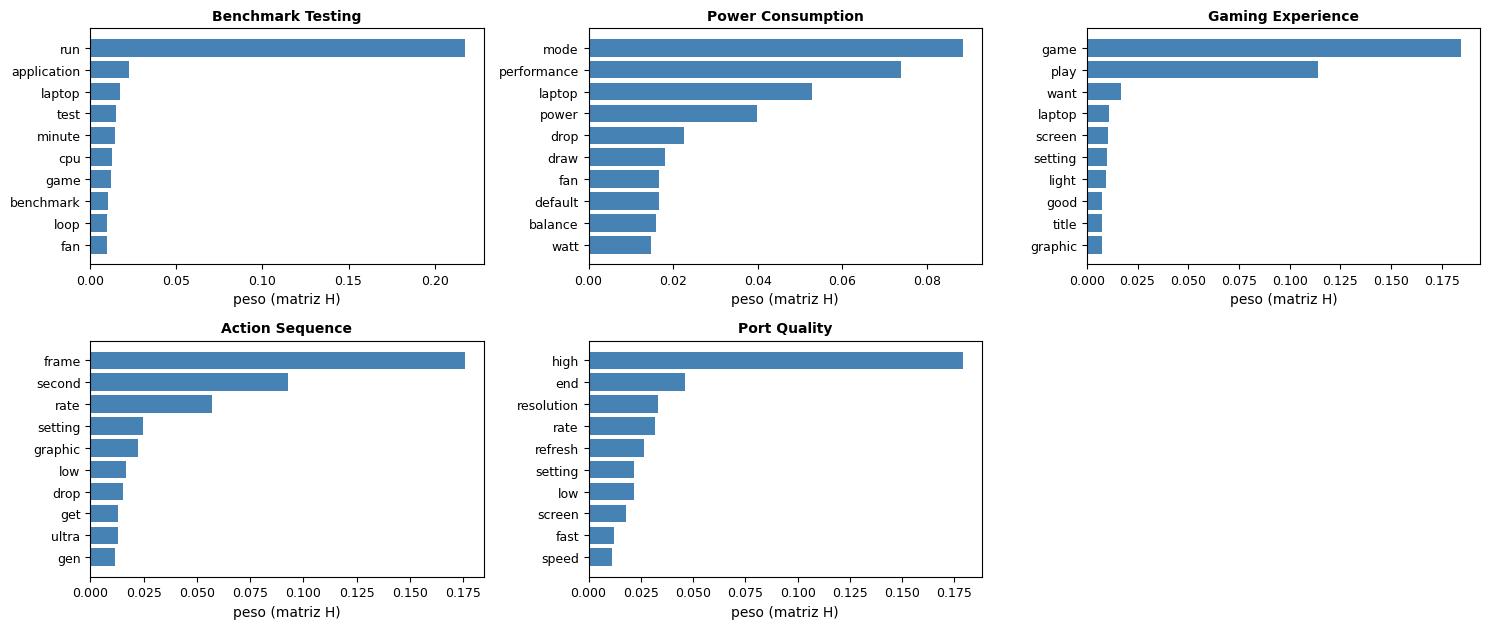

In [11]:
ncols = min(3, BEST_K)
nrows = (BEST_K + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.2 * nrows))
axes = np.atleast_1d(axes).flatten()

for tid in range(BEST_K):
    pairs = model.show_topic(tid, topn=10)
    words = [w for w, _ in pairs][::-1]
    weights = [p for _, p in pairs][::-1]
    axes[tid].barh(words, weights, color="steelblue")
    axes[tid].set_title(subtopic_names.get(tid, f"S{tid}"), fontsize=10, fontweight="bold")
    axes[tid].set_xlabel("peso (matriz H)")
    axes[tid].tick_params(labelsize=9)
for j in range(BEST_K, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "nmf_keywords_barchart.png", dpi=150, bbox_inches="tight", facecolor="white")
print(f"Salvo: {OUTPUT_DIR / 'nmf_keywords_barchart.png'}")
plt.show()


## 8. Export

Schema igual ao dos outros branches (`export_results`/`export_topics_for_eval`); a
coluna `post_id` do CSV exportado recebe o `sent_id` da sentença — pronto para um join
futuro com a tabela de revisão de
RQ4 (`04-requirements`), quando o bloqueio #1 do §5.3 (religar `stm_results.csv` de
sentença) for resolvido. Essa ligação **não** é feita aqui.


In [12]:
export_results(
    topics=dominant_sub, probs=full_sub, names=subtopic_names,
    texts=subset["sentence"].tolist(), output_path=str(OUTPUT_DIR / "nmf_results.csv"),
    topic_type="probabilistic", granularity="unit", post_ids=subset["sent_id"].tolist(),
)
export_topics_for_eval(
    topics_keywords, subtopic_names, model_name=f"nmf_restrito_topic{TOPIC_ID:02d}",
    output_path=str(OUTPUT_DIR / "nmf_topics_for_eval.csv"),
)

meta = {
    "stm_topic_id": TOPIC_ID,
    "stm_topic_name": ASPECT_TOPIC_NAMES[TOPIC_ID],
    "stm_run": STM_RUN,
    "n_sentences": len(subset),
    "best_k": BEST_K,
    "no_below": NO_BELOW,
    "no_above": NO_ABOVE,
    "npmi": float(escolhido["npmi"]),
    "diversity": float(escolhido["diversity"]),
    "cv": float(escolhido["cv"]) if "cv" in escolhido else None,
}
(OUTPUT_DIR / "nmf_final.json").write_text(json.dumps(meta, ensure_ascii=False, indent=2), encoding="utf-8")
print(f"Export concluído em {OUTPUT_DIR}")


Export concluído em ..\data\output\youtube_sent\nmf\topic12\topic12_20260922_151601
